In [1]:
# # for colab runs only
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/nlp_project/bert_run0')

In [2]:
import sys
if 'google.colab' in sys.modules:
    from IPython.core.getipython import get_ipython
    get_ipython().run_line_magic("pip", "install transformers sentencepiece accelerate")
    #get_ipython().run_line_magic("pip", "install git+https://github.com/UlisseMini/activation_additions_hf")

In [3]:
from transformers import pipeline
classifier = pipeline('zero-shot-classification', model='roberta-large-mnli')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import torch
import math
import activation_additions as aa
import random as pyrandom

import os
import csv

from typing import Dict, Union, Callable, Tuple, List
from functools import partial
from transformers import AutoModelForCausalLM, AutoTokenizer
from activation_additions.compat import get_x_vector, get_n_steered_completions, get_n_baseline_completions
from functools import lru_cache
import matplotlib.pyplot as plt
from numpy import random

import nltk
from nltk.tokenize import PunktTokenizer
from tqdm.notebook import tqdm

from numpy import array,polyfit

from datasets import load_dataset

import torch.nn.functional as F
from collections import defaultdict


In [5]:
device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"
_ = torch.set_grad_enabled(False)
device

C:\Users\oribr\AppData\Local\Temp\ipykernel_39028\1209224586.py:1: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"


'cuda'

In [6]:
MODEL = "openai-community/gpt2-xl"
# We use 16 bits percision to save time
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float16).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model.to_str_tokens = lambda t: [t.replace('Ġ', ' ') for t in tokenizer.tokenize(t)]
model.tokenizer = tokenizer
# In steering experimentation spaces were found to work well, this makes no sense and I hate it.
tokenizer.pad_token_id = int(model.tokenizer.encode(" ")[-1])
model.generation_config.pad_token_id = tokenizer.pad_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
NUM_BLOCKS = len(aa.get_blocks(model))

In [8]:
sampling_kwargs: Dict[str, Union[float, int]] = {
    "temperature": 0.6,
    "top_p": 0.5,
    "freq_penalty": 1.0,
    # "num_comparisons": 3,
    "tokens_to_generate": 50,
    "seed": 0,  # For reproducibility
}
get_x_vector_preset: Callable = partial(
    get_x_vector,
    pad_method="tokens_right",
    model=model,
    custom_pad_id=tokenizer.pad_token_id,
)

In [9]:
local_pool = load_dataset("openwebtext", split="train[:50000]")

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

plain_text/train-00078-of-00080.parquet:   0%|          | 0.00/301M [00:00<?, ?B/s]

c:\Users\oribr\Projects\NLP-project\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\oribr\.cache\huggingface\hub\datasets--openwebtext. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00079-of-00080.parquet:   0%|          | 0.00/303M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8013769 [00:00<?, ? examples/s]

In [12]:
def get_logprob_shifts(
    concept_names: List[str],
    pos_prompts: List[str],
    neg_prompts: List[str],
    layers: List[int],
    coeffs: List[float],
    dataset=local_pool,
    num_docs: int = 500,
    batch_size: int = 4,
    min_appearances: int = 20,
    max_length: int = 1024
) -> List[Dict]:
    """
    Evaluates logprob shifts across documents for multiple simultaneous concepts in batches.
    """
    assert len(pos_prompts) == len(neg_prompts) == len(layers) == len(coeffs) == len(concept_names), \
        "All input lists must be of the same length."

    # SETUP HOOKS
    print("1. Generating Activation Addition hooks...")
    all_additions = []
    for concept, p_add, p_sub, layer, coeff in zip(concept_names, pos_prompts, neg_prompts, layers, coeffs):
        additions = get_x_vector_preset(
            prompt1=p_add, 
            prompt2=p_sub, 
            coeff=coeff, 
            act_name=layer
        )
        all_additions.extend(additions)

    blocks = aa.get_blocks(model)
    hooks = [(blocks[a.layer], aa.get_hook_fn(a.coeff * a.act)) for a in all_additions]

    # Maps token: sum log log_probs 
    base_logprob_sums = defaultdict(float)
    steer_logprob_sums = defaultdict(float)
    # Maps token: number of appearences 
    token_counts = defaultdict(int)

    # PROCESS DOCUMENTS
    print(f"\n2. Shuffling local pool and evaluating {num_docs} random documents...")
    docs_to_evaluate = dataset.shuffle().select(range(num_docs))
    texts = docs_to_evaluate["text"]

    for i in tqdm(range(0, len(texts), batch_size), desc="Evaluating Batches"):
        batch_texts = texts[i : i + batch_size]
        
        # Tokenize and truncate to max length, with padding for batching
        inputs = tokenizer(
            batch_texts, 
            return_tensors='pt', 
            padding=True, 
            truncation=True, 
            max_length=max_length
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']

        # Skip if the document is too short to predict a next token
        valid_lengths = attention_mask.sum(dim=1)
        ignore_seqs = valid_lengths < 20
        attention_mask[ignore_seqs, :] = 0 
        
        if attention_mask.sum() == 0:
            continue
            
        # BASELINE FORWARD PASS
        with torch.no_grad():
            base_outputs = model(**inputs)
            base_logprobs = F.log_softmax(base_outputs.logits, dim=-1)
            
        # STEERED FORWARD PASS
        with torch.no_grad():
            with aa.pre_hooks(hooks):
                steer_outputs = model(**inputs)
                steer_logprobs = F.log_softmax(steer_outputs.logits, dim=-1)
                
        # EXTRACT PROBABILITIES
        # target_ids are the actual next tokens that appeared in the text
        target_ids = input_ids[:, 1:] 
        valid_mask = attention_mask[:, 1:] 
        
        # Gather logprobs for the actual tokens
        base_target_lps = base_logprobs[:, :-1, :].gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        steer_target_lps = steer_logprobs[:, :-1, :].gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        
        # Move to CPU immediately to free VRAM
        target_ids_cpu = target_ids.cpu()
        base_lps_cpu = base_target_lps.cpu()
        steer_lps_cpu = steer_target_lps.cpu()
        valid_mask_cpu = valid_mask.cpu()
        
        # Accumulate sums and counts ONLY for valid tokens (ignoring padding and short texts)
        for b in range(target_ids_cpu.shape[0]):
            for seq_idx in range(target_ids_cpu.shape[1]):
                if valid_mask_cpu[b, seq_idx] == 1:
                    token_id = target_ids_cpu[b, seq_idx].item()
                    base_logprob_sums[token_id] += base_lps_cpu[b, seq_idx].item()
                    steer_logprob_sums[token_id] += steer_lps_cpu[b, seq_idx].item()
                    token_counts[token_id] += 1

    # CALCULATE AVERAGES AND SHIFTS
    print("\n3. Calculating averages and filtering...")
    results = []
    for token_id, count in token_counts.items():
        if count >= min_appearances:
            avg_base = base_logprob_sums[token_id] / count
            avg_steer = steer_logprob_sums[token_id] / count
            shift = avg_steer - avg_base
            
            results.append({
                "token_id": token_id,
                "token_str": tokenizer.decode([token_id]),
                "appearances": count,
                "avg_base_logprob": avg_base,
                "avg_steer_logprob": avg_steer,
                "logprob_shift": shift
            })
            
    # Sort results by the largest positive shift (tokens that became much more likely)
    results.sort(key=lambda x: x["logprob_shift"], reverse=True)
    
    print(f"Finished. Kept {len(results)} unique tokens with >= {min_appearances} appearances.")
    return results

In [13]:
# test
retults = get_logprob_shifts(
    ["Sports", "Winter"],
    ["I talk about sports constantly", "I talk about winter constantly"],
    ["I do not talk about sports constantly", "I do not talk about winter constantly"],
    [12,5],
    [2,2],
    dataset=local_pool,
    num_docs= 500,
    min_appearances = 20,
    max_length = 1024
)


1. Generating Activation Addition hooks...

2. Shuffling local pool and evaluating 500 random documents...


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 2029 unique tokens with >= 20 appearances.


In [14]:
print(retults)

[{'token_id': 251, 'token_str': '�', 'appearances': 1147, 'avg_base_logprob': -2.975809561135775, 'avg_steer_logprob': -2.4828062009686684, 'logprob_shift': 0.49300336016710666}, {'token_id': 246, 'token_str': '�', 'appearances': 137, 'avg_base_logprob': -4.374932430956486, 'avg_steer_logprob': -3.9260618477842235, 'logprob_shift': 0.44887058317226236}, {'token_id': 250, 'token_str': '�', 'appearances': 1181, 'avg_base_logprob': -3.6495459077723647, 'avg_steer_logprob': -3.2474071210365394, 'logprob_shift': 0.40213878673582526}, {'token_id': 3877, 'token_str': ' charge', 'appearances': 27, 'avg_base_logprob': -3.2284571727116904, 'avg_steer_logprob': -2.994836273016753, 'logprob_shift': 0.23362089969493738}, {'token_id': 288, 'token_str': ' d', 'appearances': 24, 'avg_base_logprob': -6.457861582438151, 'avg_steer_logprob': -6.2435302734375, 'logprob_shift': 0.21433130900065134}, {'token_id': 5079, 'token_str': ' annual', 'appearances': 21, 'avg_base_logprob': -3.767551229113624, 'avg_s

#### Displaying the results

In [20]:
def plot_shift_distribution(results: List[Dict], concepts: List[str]) -> None:
    """
    Plots the distribution of logprob shifts across the vocabulary.
    X-axis: Tokens sorted by shift (labels omitted for cleanliness).
    Y-axis: Logprob shift magnitude.
    """
    if not results:
        print("No results to plot.")
        return

    # Extract just the shift values (already sorted descending by the main function)
    shifts = [res["logprob_shift"] for res in results]
    
    plt.figure(figsize=(10, 5))
    plt.plot(shifts, color='royalblue', linewidth=2)
    
    # Add a horizontal line at 0 for visual reference
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    concept_title = " & ".join(concepts)
    plt.title(f"Logprob Shift Distribution: {concept_title}", fontsize=14, pad=15)
    plt.ylabel("Logprob Shift (Steered - Baseline)", fontsize=12)
    plt.xlabel("Token Rank (Sorted Highest to Lowest Shift)", fontsize=12)
    
    # Grid for easier reading
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def print_top_and_bottom_shifts(results: List[Dict], concepts: List[str], x: int = 10, y: int = 10) -> None:
    """
    Prints the top 'x' tokens with the highest positive shift 
    and the bottom 'y' tokens with the lowest negative shift.
    """
    if not results:
        print("No results to print.")
        return

    concept_title = " & ".join(concepts)
    print(f"=== Extreme Logprob Shifts for: {concept_title} ===\n")
    
    print(f"Top {x} Increased Tokens (Highest Positive Shift):")
    print("-" * 60)
    for res in results[:x]:
        # repr() safely prints spaces and newlines so formatting doesn't break
        token_safe = repr(res['token_str'])
        print(f"{token_safe:<20} | Shift: {res['logprob_shift']:>7.4f} | Appearances: {res['appearances']}")
        
    print(f"\nBottom {y} Decreased Tokens (Lowest Negative Shift):")
    print("-" * 60)
    
    # Use [-y:] to get the end of the list, and reversed() so the most negative is printed first
    bottom_results = reversed(results[-y:]) if len(results) >= y else reversed(results)
    for res in bottom_results:
        token_safe = repr(res['token_str'])
        print(f"{token_safe:<20} | Shift: {res['logprob_shift']:>7.4f} | Appearances: {res['appearances']}")
    print()

def print_specific_token_stats(results: List[Dict], target_tokens: List[str]) -> None:
    """
    Searches the results for specific token strings and prints their full stats.
    Note: GPT-2 tokens often include leading spaces (e.g., ' winter' instead of 'winter').
    """
    if not results:
        print("No results to search.")
        return
        
    # Create a quick lookup dictionary for O(1) searching
    results_dict = {res["token_str"]: res for res in results}
    
    print(f"=== Stats for Specific Tokens ===")
    print("-" * 80)
    
    for token in target_tokens:
        if token in results_dict:
            res = results_dict[token]
            token_safe = repr(res['token_str'])
            print(f"Token: {token_safe:<15} | Shift: {res['logprob_shift']:>7.4f} | "
                  f"Base: {res['avg_base_logprob']:>7.4f} | Steer: {res['avg_steer_logprob']:>7.4f} | "
                  f"Count: {res['appearances']}")
        else:
            print(f"Token: {repr(token):<15} | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)")
            
    print("-" * 80)
    print()

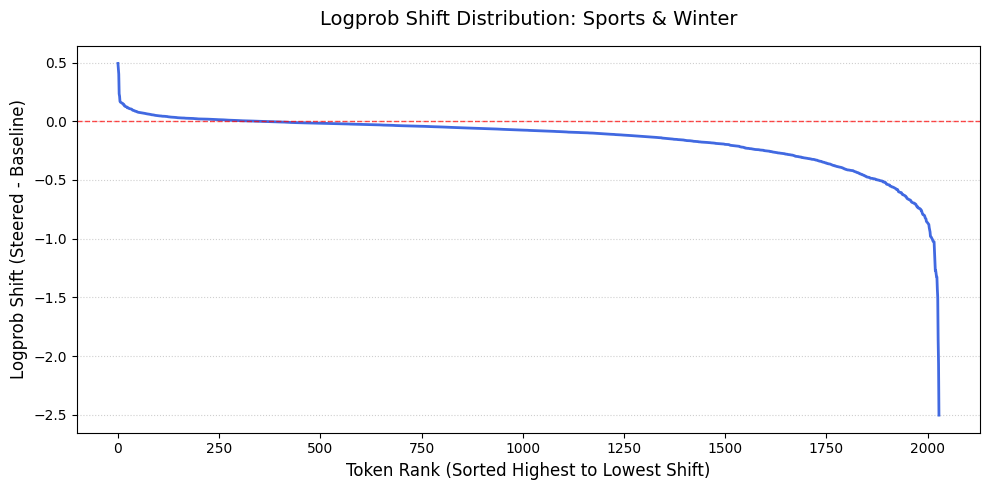

In [17]:
plot_shift_distribution(retults, ["Sports", "Winter"] )

In [19]:
print_top_and_bottom_shifts(retults, ["Sports", "Winter"], 50, 50 )

=== Extreme Logprob Shifts for: Sports & Winter ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
'�'                  | Shift:  0.4930 | Appearances: 1147
'�'                  | Shift:  0.4489 | Appearances: 137
'�'                  | Shift:  0.4021 | Appearances: 1181
' charge'            | Shift:  0.2336 | Appearances: 27
' d'                 | Shift:  0.2143 | Appearances: 24
' annual'            | Shift:  0.1703 | Appearances: 21
' Black'             | Shift:  0.1637 | Appearances: 37
' rich'              | Shift:  0.1618 | Appearances: 20
' blog'              | Shift:  0.1599 | Appearances: 20
' TV'                | Shift:  0.1569 | Appearances: 45
' cut'               | Shift:  0.1548 | Appearances: 27
' telling'           | Shift:  0.1533 | Appearances: 25
' Gu'                | Shift:  0.1518 | Appearances: 20
' talk'              | Shift:  0.1440 | Appearances: 53
' 80'                | Shift:  0.1437 | Appeara

In [22]:
tokens_to_check = [" sports", " winter", " Winter", "winter", "Winter", " Sports", " cold", " game", " trees"]
print_specific_token_stats(retults, tokens_to_check)

=== Stats for Specific Tokens ===
--------------------------------------------------------------------------------
Token: ' sports'       | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' winter'       | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' Winter'       | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: 'winter'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: 'Winter'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' Sports'       | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' cold'         | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
Token: ' game'         | Shift: -0.2208 | Base: -1.6947 | Steer: -1.9154 | Count: 129
Token: ' trees'        | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)
-------

In [8]:
def read_optimal_layers(file_path: str) -> Dict[Tuple[str, int], int]:
    """
    CSV columns: concept,optimal_layer,prompt_type  (prompt_type is 1 or 2)
    Returns: {(concept, prompt_type): optimal_layer}
    Example: {("wedding", 1): 12, ("wedding", 2): 18}
    """
    out: Dict[Tuple[str, int], int] = {}

    with open(file_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        
        for row in reader:
            concept = (row.get("Concept") or "").strip()
            if not concept:
                continue
            
            ptype = int(str(row.get("Prompt Type", "")).strip())
            
            
            layer = int(str(row.get("Optimal Layer", "")).strip())
            
            key = (concept, ptype)
            
            out[key] = layer

    return out

In [19]:
optimal_layers = read_optimal_layers("optimal_parameters.csv")

In [27]:
from pandas import read_csv
csv_file = read_csv("concepts_dataset_part_3.csv").to_dict()
concept_indexed = {}
dcat_indexed = {}
for j in csv_file["Concept"]:
    cur_data = {}
    for i in csv_file:
        cur_data[i] = csv_file[i][j]
    concept_indexed[csv_file["Concept"][j]] = cur_data
    # for i in cur_data["Dataset Categories"].split(', '):
    #     dcat_indexed[i] = cur_data["Concept"]
print(concept_indexed)
print(dcat_indexed)

{'Boxing': {'Concept': 'Boxing', 'Dataset Categories': nan, 'Keywords': nan, 'Positive Prompt Type 1': 'I talk about boxing constantly', 'Negative Prompt Type 1': "I don't talk about boxing constantly", 'Positive Prompt Type 2': 'Boxing', 'Negative Prompt Type 2': ' ', 'Positive Label': 'This text relates to boxing', 'Negative Label': 'This text does not relate to boxing'}, 'Thai': {'Concept': 'Thai', 'Dataset Categories': nan, 'Keywords': nan, 'Positive Prompt Type 1': 'I talk about Thailand constantly', 'Negative Prompt Type 1': "I don't talk about Thailand constantly", 'Positive Prompt Type 2': 'Thai', 'Negative Prompt Type 2': ' ', 'Positive Label': 'This text relates to Thailand', 'Negative Label': 'This text does not relate to Thailand'}, 'Sports': {'Concept': 'Sports', 'Dataset Categories': nan, 'Keywords': nan, 'Positive Prompt Type 1': 'I talk about sports constantly', 'Negative Prompt Type 1': "I don't talk about sports constantly", 'Positive Prompt Type 2': 'Sports', 'Negati